# ¡Tu primera Red Neuronal Convolucional (CNN)!

¡Hola! Qué bueno verte de nuevo. En el notebook anterior jugamos a ser detectives de imágenes: usamos filtros manuales para encontrar bordes verticales, horizontales y aplicamos difuminado. Todo eso multiplicando pequeñas matrices matemáticas (nuestros `kernels`) que se deslizaban por toda una imagen.

Ahora vamos a darle superpoderes a la computadora. En lugar de que tú y yo diseñemos los filtros a mano... **¡Vamos a dejar que la red neuronal aprenda sus propios filtros!**

Hoy vamos a armar una CNN desde cero con PyTorch y usaremos **PyTorch Lightning** para entrenarla súper rápido y limpio. Nuestro objetivo será construir un modelo capaz de distinguir entre las distintas letras del abecedario. ¡Manos a la obra!

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import numpy as np

# Configuramos una semilla para que, si ejecutas esto varias veces,
# los resultados aleatorios sean siempre los mismos (reproducibilidad es clave 😎)
pl.seed_everything(42)

Seed set to 42


42

--- 
## 1. El Dataset: Conoce a EMNIST (Letters)

Seguro has oído hablar de *MNIST* (el clásico dataset de numeritos escritos a mano). Bueno, hoy nos pondremos un poco más exigentes y usaremos **EMNIST** (*Extended MNIST*), específicamente la versión que solo trae letras del abecedario (A-Z).

Imagina el reto: distinguir una 'l' minúscula de un '1', o una 'O' mayúscula de un cero. ¡Afortunadamente nuestro dataset solo trae letras para enfocarnos al 100% en el abecedario!

Cada imagen en este set es un cuadrito miniatura de **28x28 píxeles** en escala de grises. Es decir, su forma en PyTorch será `[1, 28, 28]` (1 canal de color). Y como son las letras del abecedario en inglés, hay **26 clases** posibles.

In [2]:
# Preparamos una transformación sencilla: Convertir la imagen cruda a un Tensor de PyTorch
# Y una rotación pequeña porque EMNIST viene rotado 90 grados por defecto (¡una peculiaridad divertida!)
transform_emnist = transforms.Compose([
    lambda img: transforms.functional.rotate(img, -90, expand=True),
    lambda img: transforms.functional.hflip(img),
    transforms.ToTensor()
])

# Descargamos el super dataset (si no lo tienes, tardará unos segunditos)
# Ponemos split='letters' porque EMNIST tiene varios sabores.
full_dataset = torchvision.datasets.EMNIST(
    root='./data', 
    split='letters', 
    train=True, 
    download=True, 
    transform=transform_emnist
)

# EMNIST 'letters' indexa las clases del 1 al 26. 
# PyTorch prefiere que las clases vayan de 0 a 25 para trabajar más fácil internamente.
# Así que arreglamos eso restando 1 a cada etiqueta.
full_dataset.targets = full_dataset.targets - 1

# Ahora partimos nuestro dataset: un cacho grande para Entrenar y uno chiquito para Validar (ver que no memorice y sí aprenda)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Creamos los DataLoaders (nuestros meseros que sirven los datos por 'lotes' o 'batches')
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"¡Listo! Tenemos {len(train_dataset)} imágenes para entrenar y {len(val_dataset)} para validar.")

100%|██████████| 562M/562M [01:32<00:00, 6.10MB/s] 


¡Listo! Tenemos 99840 imágenes para entrenar y 24960 para validar.


### ¡Echémosle un vistazo a los datos!
No confíes ciegamente en nada. Siempre imprime unas cuantas imágenes para ver de qué trata el problema al que te enfrentas.

El lote tiene una forma loca: torch.Size([64, 1, 28, 28])
Traducción: [Bbatch_size, Canales, Alto, Ancho]


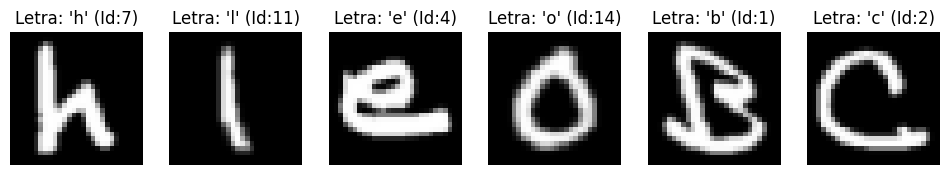

In [3]:
# Pedimos un lote de imágenes a nuestro mesero (DataLoader)
images, labels = next(iter(train_loader))

print(f"El lote tiene una forma loca: {images.shape}")
print("Traducción: [Bbatch_size, Canales, Alto, Ancho]")

# Pequeño hack para mapear números a letras (el número 0 es 'A', el 1 es 'B', etc.)
idx_to_letter = {i: chr(ord('a') + i) for i in range(26)}

# Dibujamos los primeros 6 ejemplos del lote
fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for i in range(6):
    # Tomamos la imagen 'i' del batch y la aplastamos (squeeze) porque matplotlib quiere matrices [28,28], no [1, 28, 28]
    img_to_plot = images[i].squeeze()
    axes[i].imshow(img_to_plot, cmap='gray')
    clase_num = labels[i].item()
    axes[i].set_title(f"Letra: '{idx_to_letter[clase_num]}' (Id:{clase_num})")
    axes[i].axis('off')
plt.show()

--- 
## 2. Los Ingredientes Secretos: Pooling y Flattening

Antes de armar la red, te quiero presentar dos operaciones matemáticas que vas a amar porque le facilitan la vida a tu modelo:

### A) Max Pooling (`nn.MaxPool2d`)
Imagínate que tomas una ventana (por ejemplo de 2x2 píxeles) y solo te quedas con el valor **más alto** (más brillante/fuerte) dentro de esa ventanita. 
Si haces esto por toda la imagen, estás literalmente **resumiéndola**. Reduces su ancho y alto a la mitad, quedándote solo con las "características" más resaltantes detectadas por los filtros previos. Además de que hace tus cálculos mucho más rápidos por tener menos píxeles.

### B) Flattening o Aplanamiento (`nn.Flatten`)
Las convoluciones te devuelven tensores en 3D (ej. 32 canales, por una altura y un ancho). Pero al final del día, para decidir si es una 'A' o una 'Z', solemos usar capas de neuronas clásicas (`nn.Linear`) que exigen recibir una **lista plana** de números (1D).
El `Flatten` literalmente rompe el cuadrito 3D y acomoda todos los números uno tras otro como un espagueti largo.

--- 
## 3. Construyendo a Frankenstein (Nuestra Red)

Las CNN se construyen usualmente en dos grandes bloques:
1. **El Extractor de Características (Convoluciones):** Donde la red pasa la imagen por filtros, saca bordes, luego junta bordes para hacer curvas, y usa MaxPooling para quedarse con lo mejorcito.
2. **El Clasificador (Capas Lineales o Densas):** Donde toma ese resumen súper denso de características, lo aplana, y a base de sumas y multiplicaciones decide qué letra es.

Vamos a armarlo usando la magia de `pl.LightningModule`.

In [4]:
class LetterClassifier(pl.LightningModule):
    def __init__(self):
        super().__init__()
        
        # --- PARTE 1: Extractor de Características ---
        # 
        # Capa Conv 1: Entra 1 canal (gris), sacamos 16 filtros (buscamos 16 cosas a la vez).
        # Kernel de 3x3 es el estándar moderno. Padding=1 para no encoger la imagen en este paso.
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        # MaxPooling: Resume dimensiones. De 28x28 pasará a 14x14.
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Capa Conv 2: Ahora entran los 16 canales de la capa anterior. ¡Sube tu apuesta a 32 filtros nuevos!
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        # Otro MaxPooling: Resume dimensiones. De 14x14 pasará a 7x7.
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # --- PARTE 2: Aplanado ---
        self.flatten = nn.Flatten()
        
        # --- PARTE 3: El Clasificador Final ---
        # Matemáticas rápidas: 
        # Empezamos con 28x28.
        # Pool1 lo hizo de 14x14.
        # Pool2 lo hizo de 7x7.
        # Y en ese punto tenemos 32 canales (filtros).
        # El espagueti aplanado será de tamaño: 32 canales * 7 alto * 7 ancho = 1568 numeritos.
        self.fc1 = nn.Linear(32 * 7 * 7, 128) # fc de Fully Connected. Ponemos 128 neuronas ocultas.
        self.fc2 = nn.Linear(128, 26)         # El remate final: 26 neuronas (una para cada letra!)

    def forward(self, x):
        # Aquí le decimos en qué orden pasan los datos por el bloque
        # Primero por la convolución 1, le aplicamos ReLU (para romper la linealidad) y resumimos (Pool)
        x = self.pool1(F.relu(self.conv1(x)))
        
        # Luego por la convolución 2, aplicamos ReLU y resumimos de nuevo
        x = self.pool2(F.relu(self.conv2(x)))
        
        # Aplanamos el cubo resultante a un vector largo
        x = self.flatten(x)
        
        # Lo pasamos por nuestra red neuronal clásica al final
        x = F.relu(self.fc1(x))
        x = self.fc2(x) # De aquí salen nuestras 26 log-probabilidades crudas (logits)
        return x

    # ========= RUTINA DE ENTRENAMIENTO DE LIGHTNING ========= #
    # Nos ahorra hacer los loops 'for epoch' gigantes.
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x) # Llamada automática al 'forward'
        
        # CrossEntropyLoss es el estándar oro para problemas de clasificación de múltiples clases
        loss = F.cross_entropy(y_hat, y)
        
        # Opcional: Registrar el error en consola
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        # Adam es un optimizador muy inteligente que ajusta la velocidad de aprendizaje (learning rate) solito
        return torch.optim.Adam(self.parameters(), lr=1e-3)

--- 
## 4. ¡A Entrenar se ha dicho!

El chiste de Lightning es que no tenemos que programar los detalles complejos del movimiento de tensores a la GPU (tarjeta gráfica) o de iterar manualmente por el DataLoader. Todo se hace mediante un `Trainer`.

In [5]:
# 1. Instanciamos nuestro flamante modelo recién definido
model = LetterClassifier()

# 2. Creamos al entrenador. 
# Le pedimos entrenar por 3 "epochs". 
# (Un epoch significa que la red vio TODAS las imágenes del dataset de entrenamiento 1 sola vez)
trainer = pl.Trainer(max_epochs=3, accelerator='auto')

# 3. ¡Que inicie la magia! (Dale unos 30 segundos o pocos minutos dependiendo tu compu)
trainer.fit(model, train_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\efrai\OneDrive\Desktop\EF\Education\Professor\DL classes\uag-deep-learning\venv\lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/li

Epoch 2: 100%|██████████| 1560/1560 [00:35<00:00, 43.92it/s, v_num=0, train_loss=0.212] 

`Trainer.fit` stopped: `max_epochs=3` reached.


Epoch 2: 100%|██████████| 1560/1560 [00:35<00:00, 43.90it/s, v_num=0, train_loss=0.212]


--- 
## 5. ¡A Jugar! Predicciones en Vivo

Tu red ahora "ya se sabe" el abecedario muy bien. Vamos a agarrar unas cuantas imágenes del **set de validación** (imágenes que la red NUNCA vio al entrenar) y a pedirle que nos diga qué letras cree que son.

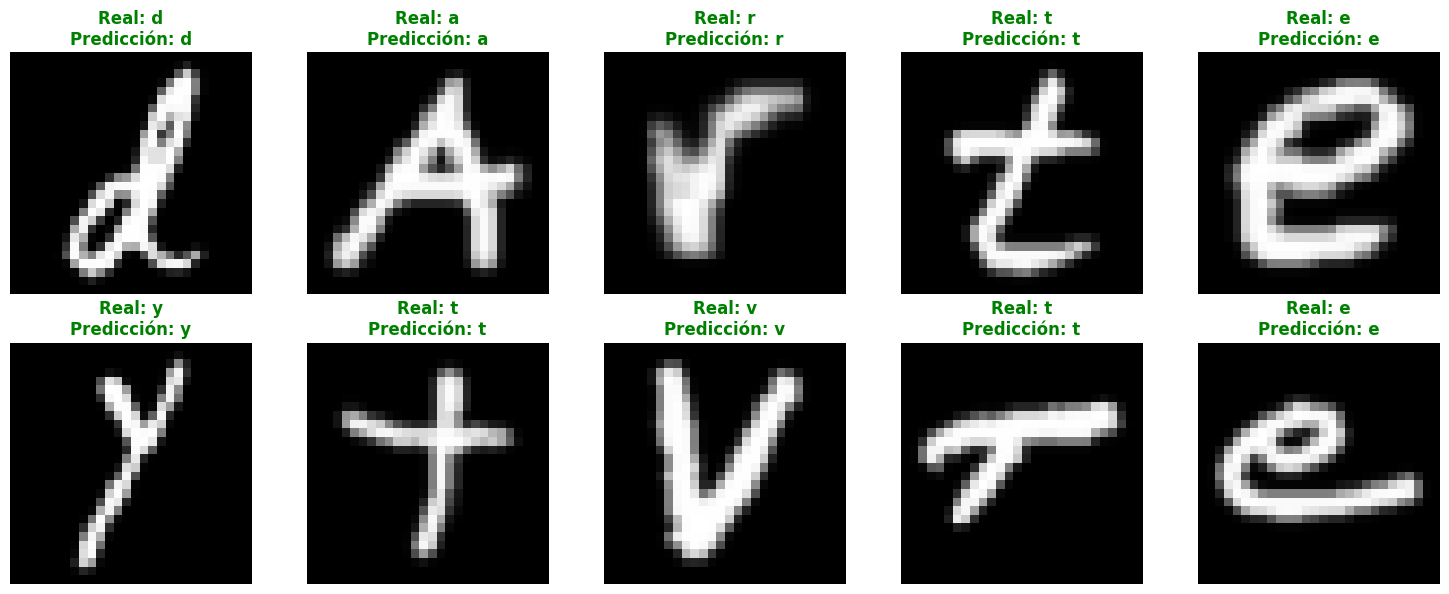

In [8]:
model.eval() # Modo evaluación (apaga cosas irrelevantes como el Dropout si lo tuviéramos)

# Tomamos un batch de validación (es la prueba final de fuego!)
val_images, val_labels = next(iter(val_loader))

with torch.no_grad(): # Le pedimos a PyTorch que no guarde memoria de los gradientes (es más rápido así para predecir)
    # Le pasamos todo el lote de imágenes frescas (¡64 de jalón!) al modelo para que prediga.
    predicciones = model(val_images)
    # Las predicciones son 26 números por imagen. Queremos quedarnos con el número (clase) que tuvo mayor puntaje.
    # El comando torch.argmax nos devuelve el 'índice' de la columna con el número mayor.
    predicciones_clase = torch.argmax(predicciones, dim=1)

# Visualizamos las primeras 10
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img_to_plot = val_images[i].squeeze()
    
    ax.imshow(img_to_plot, cmap='gray')
    
    letra_real = idx_to_letter[val_labels[i].item()]
    letra_predicha = idx_to_letter[predicciones_clase[i].item()]
    
    # Titulamos en verde si atinó, y rojo si falló.
    color = "green" if letra_real == letra_predicha else "red"
    ax.set_title(f"Real: {letra_real}\nPredicción: {letra_predicha}", color=color, fontweight='bold')
    ax.axis('off')
    
plt.tight_layout()
plt.show()

¡Increíble! Seguramente la red le atinó a la inmensa mayoría casi instantáneamente a pesar de la enorme variabilidad de la escritura humana. Ese es el inmenso poder de las Convoluciones: entienden formas, curvas y trazos sin importar donde estén posicionados exactamente en el cuadrito (esto se conoce como **invarianza traslacional**).

---
## 🏋️‍♂️ Tu Misión (Tarea Extraclase)

¿Crees que puedes descifrar qué siente una persona viendo una foto de su cara?

Existen conjuntos de datos como **FER-2013** (Facial Expression Recognition) que contienen imágenes en escala de grises, ligeramente más grandes (normalmente 48x48), categorizadas en emociones: Enojo, Asco, Miedo, Felicidad, Tristeza, Sorpresa, Neutral.

**El Reto:** 
1. Busca si puedes usar otro Dataset integrado como `torchvision.datasets.FER2013` (o cargar uno equivalente usando `ImageFolder` si lo descargas a mano).
2. Copia la clase `LetterClassifier` y renómbrala a `EmotionDetector`.
3. **Realiza la ingeniería matemática!** Dado que las imágenes ya no serán de 28x28 píxeles sino posiblemente de 48x48, deberás calcular las matemáticas del `Flatten` nuevamente para conectar tus Convoluciones a las primeras `nn.Linear` del clasificador.
4. ¡Cambia la última capa `self.fc2`! Las emociones de los rostros usualmente son 7 clases, ¡ya no son 26!
5. Entrena y evalúa tus resultados en Python.

¡Muchísimo éxito, arquitecto(a) de redes!